# Predicción del Salario de un Beisbolista en función de su rendimiento

#### Aplicamos AdaBoosting y Gradient Boosting


In [49]:
# Importar las librerias

# Cargamos nuestras librerias
import numpy as np
import pandas as pd

# Entorno SciKit Learn
from sklearn.linear_model import LinearRegression   #

from sklearn.model_selection import train_test_split  # Dividir el conjunto de prueba y entrenamiento
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score # Validación cruzada
from sklearn.model_selection import cross_validate # Validación cruzada
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

# Para preprocesamiento
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler  # La libreria para reescalar datos
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
datos=pd.read_csv("hitters.csv")

In [68]:
datos.info() # Tenemos datos faltantes en el atributo salario

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [69]:
datos=datos[np.isnan(datos["Salary"])!=True]  # Eliminamos los datos faltantes. 

In [70]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64

# Análisis de los outliers en el Salario

{'whiskers': [<matplotlib.lines.Line2D at 0x162fc410910>,
 'caps': [<matplotlib.lines.Line2D at 0x162fc410e50>,
 'boxes': [<matplotlib.lines.Line2D at 0x162fc410670>],
 'medians': [<matplotlib.lines.Line2D at 0x162fc41a3d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x162fc41a670>],
 'means': []}

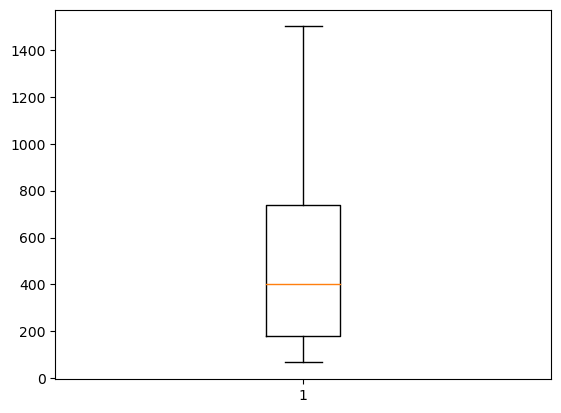

In [73]:
plt.boxplot(datos["Salary"])

In [72]:
# Calculamos el primero y tercer cuartil
quartiles=np.quantile(datos["Salary"],q=[0.25,0.75])
RI=quartiles[1]-quartiles[0]
datos=datos[datos["Salary"]<=(quartiles[1]+1.5*RI)]


In [74]:
#Recodificar las variables de tipo Objeto.
datos["League"].replace({"A":0,"N":1}, inplace=True)
datos["Division"].replace({"E":0,"W":1}, inplace=True)
datos["NewLeague"].replace({"A":0,"N":1}, inplace=True)

In [75]:
datos.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,1,1,632,43,10,475.0,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,0,1,880,82,14,480.0,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,1,0,200,11,3,500.0,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,1,0,805,40,4,91.5,1
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,0,1,282,421,25,750.0,0


<Axes: xlabel='Hits', ylabel='Salary'>

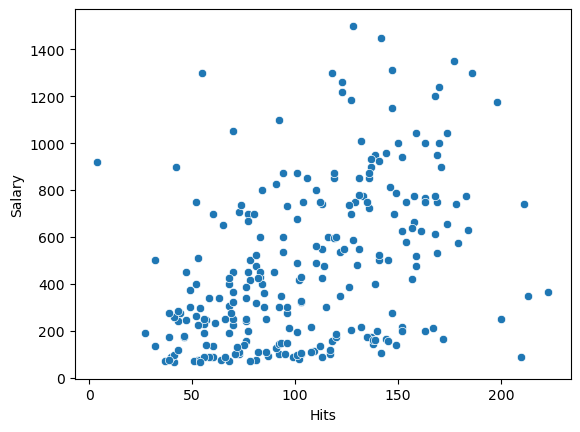

In [80]:
# Cómo se ve la relación entre el salario y el número de Hits
sns.scatterplot(x="Hits", y="Salary", data=datos)

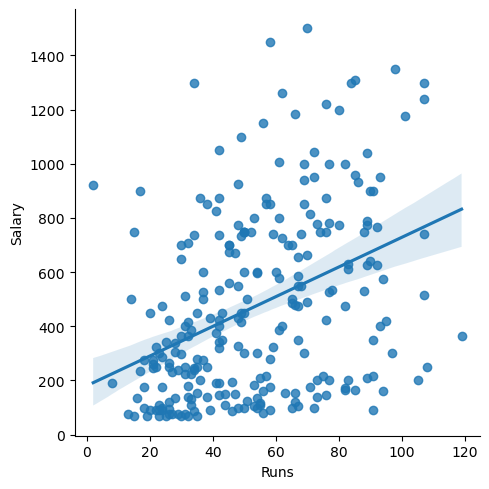

In [81]:
sns.lmplot(x="Runs", y="Salary", data=datos)

In [82]:
# Qué atributos están más correlacionados con el Salario
datos.corr()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
AtBat,1.000000,0.966409,0.538008,0.898066,0.786338,0.601065,-0.021450,0.165157,0.179679,0.163728,0.186658,0.171466,0.077018,-0.139060,-0.034117,0.282219,0.377128,0.339554,0.410757,-0.072070
Hits,0.966409,1.000000,0.517288,0.908682,0.776879,0.552461,-0.013311,0.164306,0.187386,0.134847,0.186210,0.164333,0.062973,-0.133533,-0.050164,0.254088,0.337611,0.291423,0.429405,-0.070622
HmRun,0.538008,0.517288,1.000000,0.618100,0.853150,0.436523,0.090600,0.188889,0.184948,0.467662,0.220710,0.318598,0.195622,-0.216057,-0.020909,0.211784,-0.130832,0.007615,0.352955,-0.191426
Runs,0.898066,0.908682,0.618100,1.000000,0.767810,0.671656,-0.051394,0.121033,0.133959,0.177725,0.174049,0.142674,0.094205,-0.193200,-0.072041,0.227335,0.213962,0.207672,0.392115,-0.138046
RBI,0.786338,0.776879,0.853150,0.767810,1.000000,0.545075,0.090062,0.225095,0.233626,0.385376,0.244965,0.324529,0.173279,-0.175664,-0.054895,0.257168,0.093895,0.165035,0.423626,-0.130555
Walks,0.601065,0.552461,0.436523,0.671656,0.545075,1.000000,0.100886,0.216649,0.210269,0.316596,0.269852,0.258423,0.371436,-0.054104,-0.027649,0.249117,0.110427,0.072114,0.394934,-0.013949
Years,-0.021450,-0.013311,0.090600,-0.051394,0.090062,0.100886,1.000000,0.916856,0.900949,0.731855,0.882780,0.874354,0.843388,-0.035489,-0.007539,-0.053550,-0.075055,-0.155397,0.467476,-0.026506
CAtBat,0.165157,0.164306,0.188889,0.121033,0.225095,0.216649,0.916856,1.000000,0.995480,0.801124,0.984379,0.954116,0.905655,-0.019283,0.012622,0.006871,0.005190,-0.071741,0.564164,0.000659
CHits,0.179679,0.187386,0.184948,0.133959,0.233626,0.210269,0.900949,0.995480,1.000000,0.780630,0.984910,0.947177,0.887141,-0.013897,0.012282,0.014727,0.001413,-0.070040,0.578269,0.010677
CHmRun,0.163728,0.134847,0.467662,0.177725,0.385376,0.316596,0.731855,0.801124,0.780630,1.000000,0.822230,0.923623,0.822751,-0.101226,0.008334,0.031095,-0.163883,-0.168917,0.505362,-0.094311


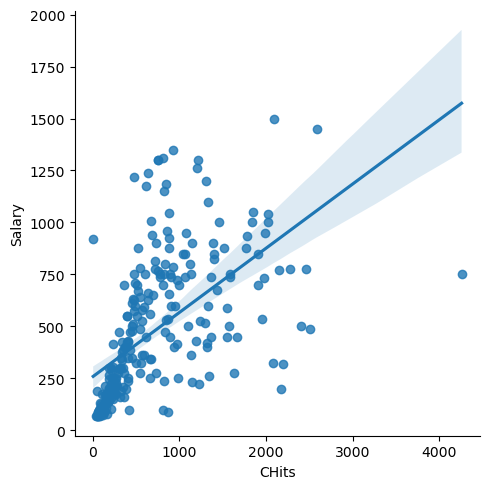

In [85]:
# La relación más alta..
sns.lmplot(x="CHits", y="Salary", data=datos)

In [86]:
# target y los atributos
y=datos["Salary"]
del datos["Salary"]
X=datos

In [87]:
# Seleccionamos el conjunto de entrenamiento y prueba para ajustar un modelo
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=1234)

In [88]:
# Definimos el modelo
modelo=LinearRegression()
modelo.fit(X_train,y_train)

LinearRegression()

In [89]:
# Medimos ahora el desempeño predictivo del modelo
y_pred=modelo.predict(X_test)

In [94]:
#Mean Absolute errro
np.abs(y_test-y_pred).mean()

172.07334712879288

In [97]:
#Esta métrica depende del conjunto de entrenamiento y prueba
#Hacemos una validación cruzada para tener una métrica más robusta

scores=cross_val_score(modelo,X,y,scoring="neg_mean_absolute_error",cv=10,n_jobs=-1)
print("El error absoluto promedio es {:.3f} +/- {:.3f} ".format(-scores.mean(),scores.std()))


El error absoluto promedio es 201.569 +/- 29.437 


In [99]:
-scores

array([238.48106622, 140.59265691, 204.54592233, 193.14496435,
       215.23856039, 216.5734064 , 162.96118219, 189.44281797,
       219.43623549, 235.27221392])

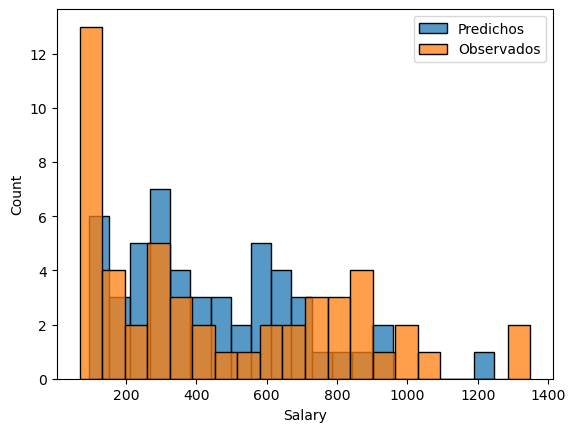

In [104]:
sns.histplot(y_pred, label="Predichos", bins=20)
sns.histplot(y_test, label="Observados", bins=20)
plt.legend()


In [105]:
modelo.coef_

array([-7.34441227e-01,  5.61781807e+00,  1.10758193e+01, -4.41122557e+00,
       -3.85359104e+00,  5.42354487e+00,  2.71515262e+00,  2.31434815e-02,
       -4.52538282e-01, -1.53316658e+00,  1.34080107e+00,  8.50000193e-01,
       -8.73971955e-01,  7.59585815e+01, -7.16677252e+01,  1.93715496e-01,
        8.25769344e-02, -2.70130850e+00, -5.98561244e+01])

In [107]:
import statsmodels.api as sm
X_train = sm.add_constant(X_train, prepend=True)
modelo = sm.OLS(endog=y_train, exog=X_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     9.263
Date:                Mon, 09 Oct 2023   Prob (F-statistic):           3.00e-18
Time:                        19:41:02   Log-Likelihood:                -1385.4
No. Observations:                 201   AIC:                             2811.
Df Residuals:                     181   BIC:                             2877.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.2185     86.056      0.769      0.4

In [123]:
modelo = sm.OLS(endog=y_train, exog=X_train[['const', 'Walks',
       'CRuns', 'CWalks', 'Division', 'PutOuts']])
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     32.32
Date:                Mon, 09 Oct 2023   Prob (F-statistic):           6.32e-24
Time:                        20:14:18   Log-Likelihood:                -1393.0
No. Observations:                 201   AIC:                             2798.
Df Residuals:                     195   BIC:                             2818.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         91.8995     48.260      1.904      0.0